In [54]:
import sys
sys.path.append('..')

%load_ext autoreload
%autoreload 2

from src.data_loader import TICKERS, load_or_fetch_prices
from src.analytics import compute_log_returns, compute_rolling_volatility, compute_correlation_matrix, run_pca, rebase_prices
from src.visualisation import plot_prices, plot_log_returns, plot_correlation_heatmap, plot_pca_summary, plot_rolling_volatility
from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
prices = load_or_fetch_prices(
    tickers=TICKERS,
    start="2020-01-01",
    end="2026-05-01",
    cache_path=Path("../data/commodity_prices.csv")
)

print(prices.head())
print(prices.shape)

            Crude_Oil  Natural_Gas  Copper
Date                                      
2020-01-02  61.180000       2.8330   2.122
2020-01-03  63.049999       2.7985   2.130
2020-01-06  63.270000       2.8005   2.135
2020-01-07  62.700001       2.8040   2.162
2020-01-08  59.610001       2.8190   2.141
(1593, 3)


In [56]:
rebased_prices = rebase_prices(prices)
log_returns = compute_log_returns(prices)
rolling_vol = compute_rolling_volatility(log_returns)
corr_matrix = compute_correlation_matrix(log_returns)
pca_results = run_pca(log_returns, n_components=3)

c:\Users\addzz\Desktop\Code\quant-projects-roadmap\commodity-price-dashboard\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


## 1. Price History (Rebased)

Raw prices across three commodities are difficult to compare directly - 
WTI crude trades near $80, copper near $4, and natural gas below $3. 
Rebasing each series to 1 at the start date removes the scale difference 
and lets us compare relative performance over time.

**What to look for:** Which commodity recovered fastest post-COVID? 
Which was most affected by the Russia-Ukraine energy shock in 2022?

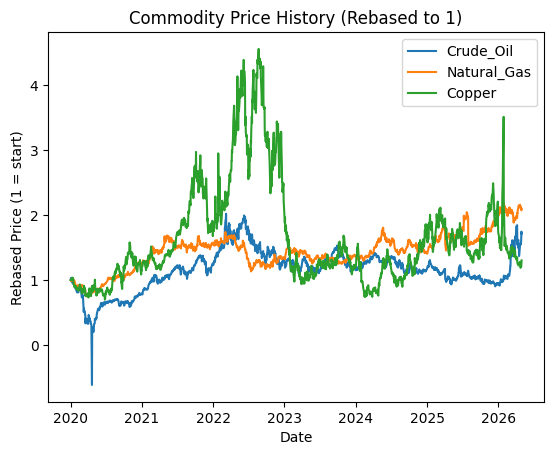

In [66]:
fig = plot_prices(rebased_prices)
fig.savefig("../assets/prices.png", dpi=150, bbox_inches="tight")

## 2. Log Returns

We transform prices into log returns: `r_t = ln(P_t / P_{t-1})`. 
Log returns are additive across time and produce a more symmetric 
distribution than simple returns — both useful properties for 
statistical analysis.

**What to look for:** Volatility clustering — periods where large 
returns are followed by more large returns. This is one of the most 
well-documented stylised facts in financial time series.

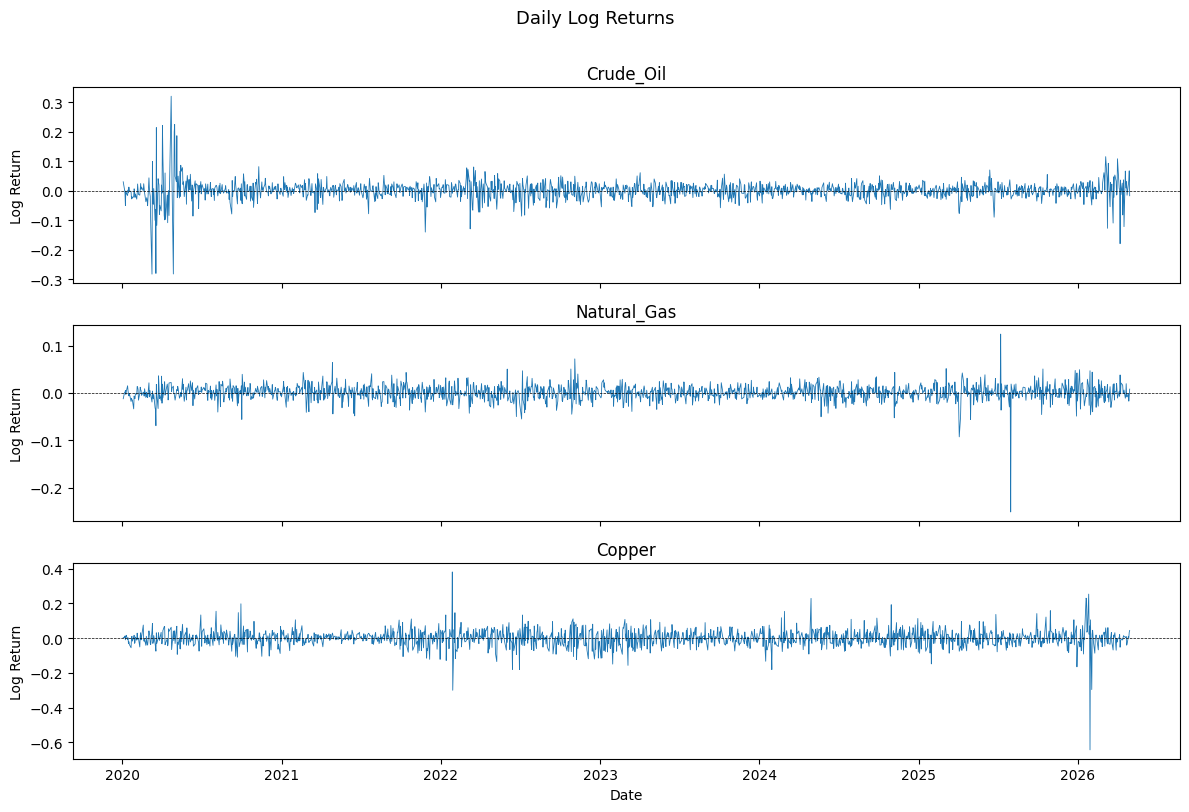

In [71]:
fig = plot_log_returns(log_returns)
fig.savefig("../assets/log_returns.png", dpi=150, bbox_inches="tight")

## 3. Rolling Volatility (30-Day)

Rolling 30-day annualised volatility captures how uncertainty in each 
market changes over time. Annualisation uses the sqrt(252) scaling 
rule — daily variance scales linearly with time, so daily standard 
deviation scales with the square root.

**What to look for:** Do volatility spikes coincide with known market 
events — COVID (March 2020), the energy crisis (2022), tariff 
announcements (2025)?

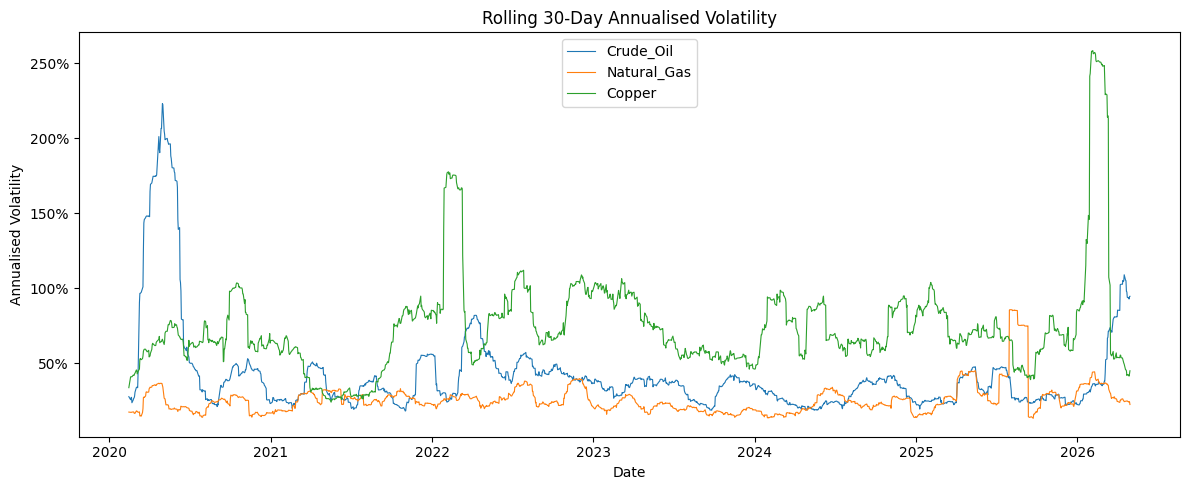

In [75]:
fig = plot_rolling_volatility(rolling_vol)
fig.savefig("../assets/rolling_volatility.png", dpi=150, bbox_inches="tight")

## 4. Correlation Matrix

The Pearson correlation matrix measures linear co-movement between 
asset pairs, normalised to [-1, 1]. A high positive correlation means 
the assets tend to move together — they share common risk factors.

**What to look for:** Is crude oil more correlated with natural gas 
or copper? Does the answer make economic sense given what drives 
each market?

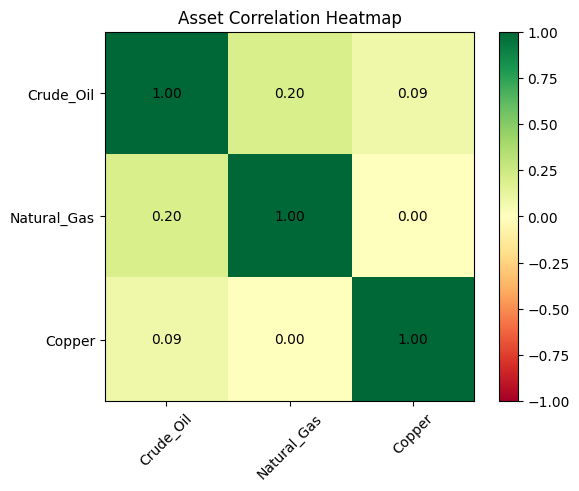

In [78]:
fig = plot_correlation_heatmap(corr_matrix)
fig.savefig("../assets/correlation_heatmap.png", dpi=150, bbox_inches="tight")

## 5. Principal Component Analysis

PCA decomposes the covariance matrix of returns into eigenvectors 
(directions of maximum variance) and eigenvalues (magnitude of 
variance along each direction). This reveals the underlying risk 
factors driving co-movement across all three commodities.

**What to look for:** How many components are needed to explain 90% 
of total variance? If PC1 explains most variance, it suggests a 
single dominant macro factor — likely global growth or dollar 
strength — drives all three markets simultaneously.

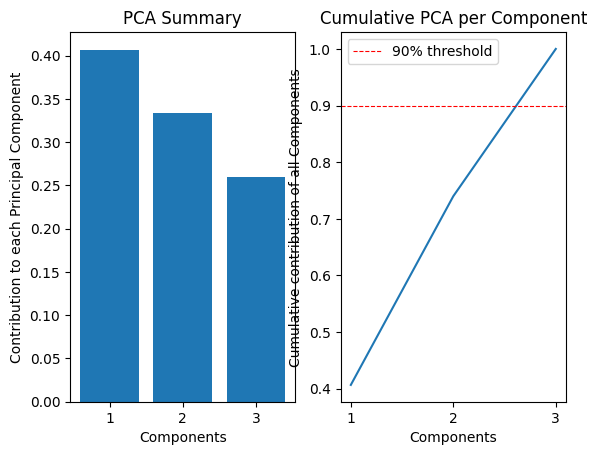

In [80]:
fig = plot_pca_summary(pca_results)
fig.savefig("../assets/pca_summary.png", dpi=150, bbox_inches="tight")